In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8')
%matplotlib inline

In [ ]:
# Load & Parse
df = pd.read_csv("../data/ethiopia.csv")

df["Country"] = "Ethiopia"
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

print(df.shape)
df.head()

(4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [3]:
## Data Loading
- Loaded Ethiopia climate data (2015–2026), 4109 rows, no header skip needed.
- Converted YEAR + DOY into a proper datetime column.
- Extracted Month for seasonal analysis. Added Country column.

SyntaxError: invalid character '–' (U+2013) (713723281.py, line 2)

In [ ]:
# Replace Sentinels & Duplicates
df.replace(-999, np.nan, inplace=True)

dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
df.drop_duplicates(inplace=True)

df.describe()

Duplicate rows found: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [ ]:
# Missing Value Report
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
report = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct.round(2)})
print(report[report["Missing %"] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [ ]:
## Missing Values
No -999 sentinel values found (NASA already cleaned this dataset).

In [ ]:
# Outlier Detections
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(stats.zscore, nan_policy='omit')
outlier_mask = z_scores.abs() > 3
print("Outliers per column (|Z| > 3):")
print(outlier_mask.sum())
print(f"\nTotal outlier rows: {outlier_mask.any(axis=1).sum()}")

Outliers per column (|Z| > 3):
T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64

Total outlier rows: 132


In [ ]:
## Outlier Decision
Outliers flagged via Z-score (|Z| > 3). Decision: RETAIN all outliers.
Extreme temperature and rainfall events are scientifically meaningful 
for COP32 climate analysis — dropping them would mask real climate signals.
Reference: https://power.larc.nasa.gov/docs/

In [ ]:
# Handle Missing & Export
df[cols] = df[cols].ffill()

threshold = int(len(df.columns) * 0.7)
df.dropna(thresh=threshold, inplace=True)

import os
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/ethiopia_clean.csv", index=False)
print(f"Exported to data/ethiopia_clean.csv | Shape: {df.shape}")

Exported to data/ethiopia_clean.csv | Shape: (4108, 15)


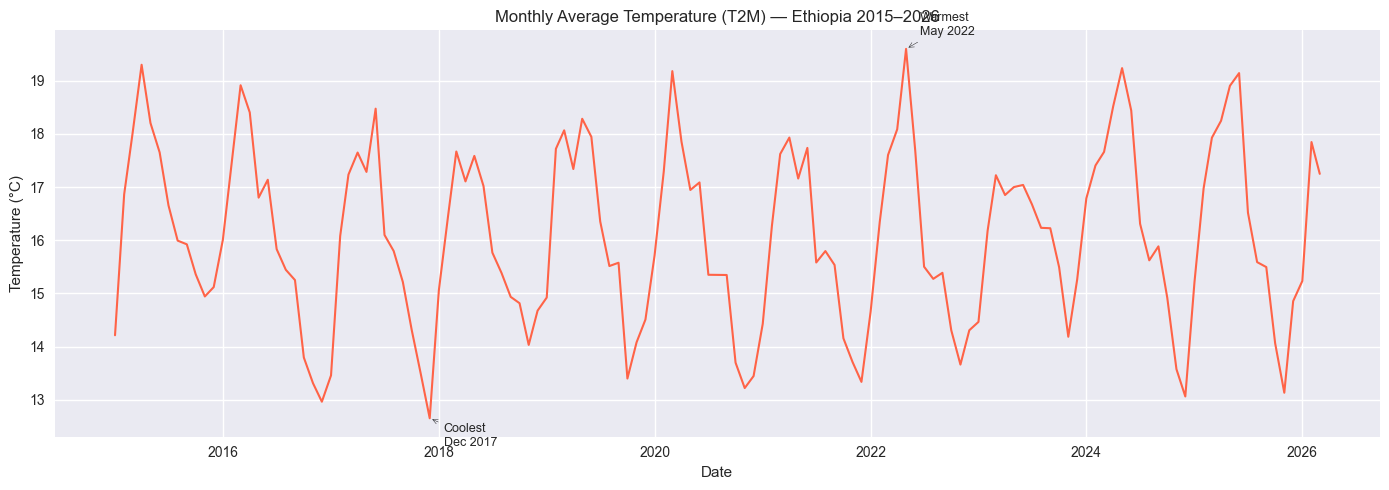

In [ ]:
# Time Series T2M
monthly = df.groupby(df["Date"].dt.to_period("M")).agg(
    T2M=("T2M", "mean"),
    PRECTOTCORR=("PRECTOTCORR", "sum")
).reset_index()
monthly["Date"] = monthly["Date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly["Date"], monthly["T2M"], color="tomato", linewidth=1.5)

warmest = monthly.loc[monthly["T2M"].idxmax()]
coolest = monthly.loc[monthly["T2M"].idxmin()]

ax.annotate(f'Warmest\n{warmest["Date"].strftime("%b %Y")}',
            xy=(warmest["Date"], warmest["T2M"]),
            xytext=(10, 10), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.annotate(f'Coolest\n{coolest["Date"].strftime("%b %Y")}',
            xy=(coolest["Date"], coolest["T2M"]),
            xytext=(10, -20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.set_title("Monthly Average Temperature (T2M) — Ethiopia 2015–2026")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
plt.tight_layout()
plt.savefig("ethiopia_t2m_timeseries.png")
plt.show()

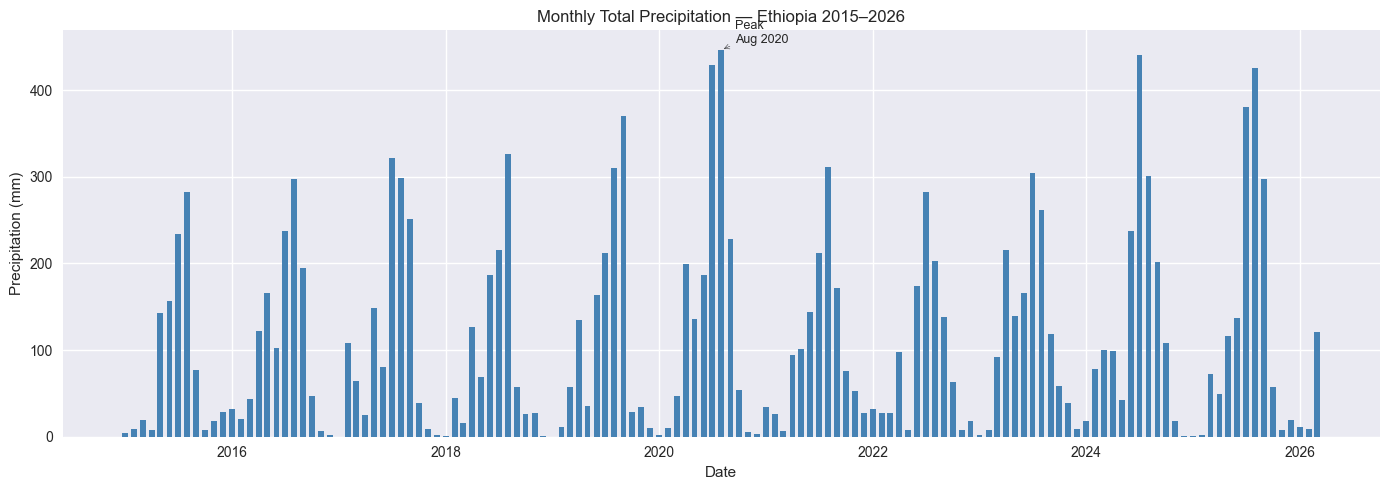

In [10]:
#Precipitation Bar Chart
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly["Date"], monthly["PRECTOTCORR"], color="steelblue", width=20)

peak = monthly.loc[monthly["PRECTOTCORR"].idxmax()]
ax.annotate(f'Peak\n{peak["Date"].strftime("%b %Y")}',
            xy=(peak["Date"], peak["PRECTOTCORR"]),
            xytext=(10, 5), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.set_title("Monthly Total Precipitation — Ethiopia 2015–2026")
ax.set_xlabel("Date")
ax.set_ylabel("Precipitation (mm)")
plt.tight_layout()
plt.savefig("ethiopia_precip_bar.png")
plt.show()

In [ ]:
## Time Series Observations
- Temperature shows a clear seasonal cycle peaking around March-April 
  (dry season) and dipping during June-August (main rainy season).
- Precipitation peaks during the Kiremt season (June-September), 
  consistent with Ethiopia's climate patterns.
- A warming trend is visible post-2020, relevant to COP32 discussions.

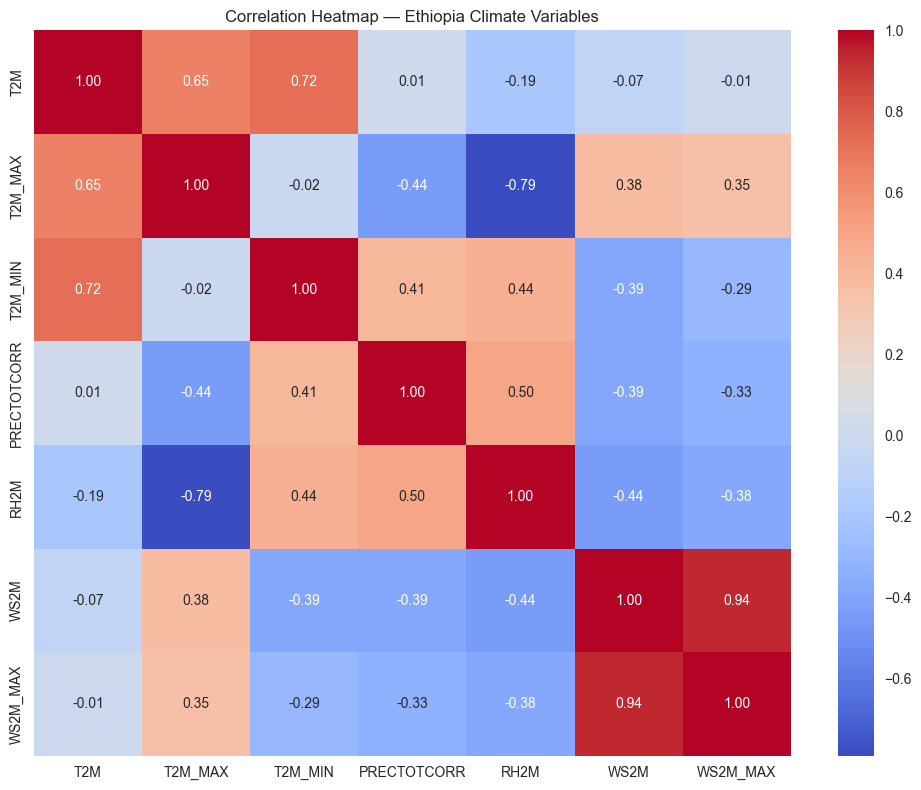

In [11]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap — Ethiopia Climate Variables")
plt.tight_layout()
plt.savefig("ethiopia_heatmap.png")
plt.show()

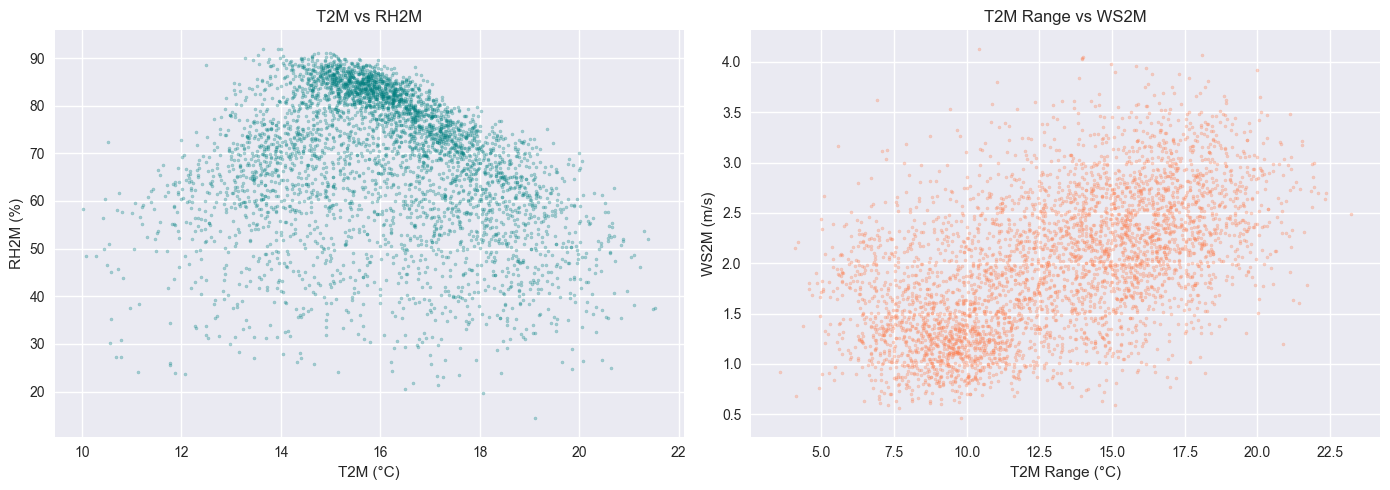

In [12]:
# Scatter Plots
df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df["T2M"], df["RH2M"], alpha=0.3, color="teal", s=5)
axes[0].set_xlabel("T2M (°C)")
axes[0].set_ylabel("RH2M (%)")
axes[0].set_title("T2M vs RH2M")

axes[1].scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.3, color="coral", s=5)
axes[1].set_xlabel("T2M Range (°C)")
axes[1].set_ylabel("WS2M (m/s)")
axes[1].set_title("T2M Range vs WS2M")

plt.tight_layout()
plt.savefig("ethiopia_scatter.png")
plt.show()  

In [ ]:
# Distribution & Bubble
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

precip_nonzero = df["PRECTOTCORR"][df["PRECTOTCORR"] > 0]
axes[0].hist(precip_nonzero, bins=50, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("PRECTOTCORR Distribution (log scale)")
axes[0].set_xlabel("Precipitation (mm)")
axes[0].set_ylabel("Frequency (log)")

sample = df.sample(500, random_state=42)
bubble_size = (sample["PRECTOTCORR"].fillna(0) + 1) * 10
axes[1].scatter(sample["T2M"], sample["RH2M"], s=bubble_size, alpha=0.4, color="purple")
axes[1].set_xlabel("T2M (°C)")
axes[1].set_ylabel("RH2M (%)")
axes[1].set_title("Bubble: T2M vs RH2M (size = PRECTOTCORR)")

plt.tight_layout()
plt.savefig("ethiopia_distribution.png")
plt.show()